# 02 — Traditional Pipeline (HOG + LBP + Intensity → RBF-SVM)

Handcrafted features — a 64-bin intensity histogram, HOG, and a uniform LBP histogram
(8190-d) — classified with an RBF-SVM. Outputs are written to `results/traditional/`.

In [1]:
import os, sys, json, time
import numpy as np
import pandas as pd
# Make the project root importable whether run from notebooks/ or the project root.
cwd = os.getcwd()
ROOT = cwd if os.path.isdir(os.path.join(cwd, "src")) else os.path.dirname(cwd)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
from src.dataset import PROJECT_ROOT
from src.evaluate import seed_everything
from IPython.display import Image, display, Markdown
seed_everything(42)

import joblib
from src.dataset import CLASSES, TRAIN_DIR, TEST_DIR, scan_samples
from src.features import extract_dataset
from src.traditional import build_pipeline
from src.evaluate import compute_metrics, save_confusion_matrix, file_size_mb, save_json
TRAD_DIR = os.path.join(PROJECT_ROOT, "results", "traditional")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
os.makedirs(TRAD_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

## Feature extraction (train + test)

In [2]:
train_samples = scan_samples(TRAIN_DIR)
test_samples = scan_samples(TEST_DIR)
X_train, y_train, t_train = extract_dataset(train_samples, "train-features")
X_test, y_test, t_test = extract_dataset(test_samples, "test-features")
print(f"Feature dim: {t_train['feature_dim']}  "
      f"(train {t_train['total_sec']:.1f}s, {t_train['per_image_ms']:.2f} ms/img)")

Feature dim: 8190  (train 49.5s, 18.03 ms/img)


## Train RBF-SVM and evaluate on the test set

In [3]:
pipe = build_pipeline()
t0 = time.perf_counter(); pipe.fit(X_train, y_train); fit_time = time.perf_counter() - t0
t1 = time.perf_counter(); y_pred = pipe.predict(X_test); pred_time = time.perf_counter() - t1
scores = pipe.decision_function(X_test)
metrics = compute_metrics(y_test, y_pred, CLASSES)
n_sv = int(pipe.named_steps["svm"].n_support_.sum())
model_path = os.path.join(MODELS_DIR, "traditional_pipeline.joblib")
joblib.dump(pipe, model_path)
model_size = file_size_mb(model_path)
inference_ms = t_test["per_image_ms"] + pred_time / len(test_samples) * 1000.0
train_time = t_train["total_sec"] + fit_time
out = dict(metrics)
out.update({
    "feature_dim": t_train["feature_dim"],
    "feat_extract_train_sec": t_train["total_sec"],
    "feat_extract_train_per_image_ms": t_train["per_image_ms"],
    "feat_extract_test_per_image_ms": t_test["per_image_ms"],
    "svm_fit_sec": fit_time, "svm_predict_sec": pred_time,
    "train_time_sec": train_time, "inference_ms_per_image": inference_ms,
    "model_size_mb": model_size, "n_support_vectors": n_sv,
    "n_train": len(train_samples), "n_test": len(test_samples), "model": "Handcrafted+SVM",
})
save_json(out, os.path.join(TRAD_DIR, "traditional_metrics.json"))
save_confusion_matrix(metrics["confusion_matrix"], CLASSES,
    f"Traditional (HOG+LBP+SVM) - Acc {metrics['accuracy']*100:.1f}%",
    os.path.join(TRAD_DIR, "cm_traditional.png"))
np.savez(os.path.join(TRAD_DIR, "traditional_test_outputs.npz"),
         y_true=y_test, y_pred=y_pred, scores=scores)
print(f"Accuracy {metrics['accuracy']*100:.2f}%  Macro-F1 {metrics['macro_f1']*100:.2f}%  "
      f"| {n_sv} SVs, {model_size:.1f} MB")

Accuracy 85.98%  Macro-F1 84.64%  | 2747 SVs, 172.2 MB


## Results

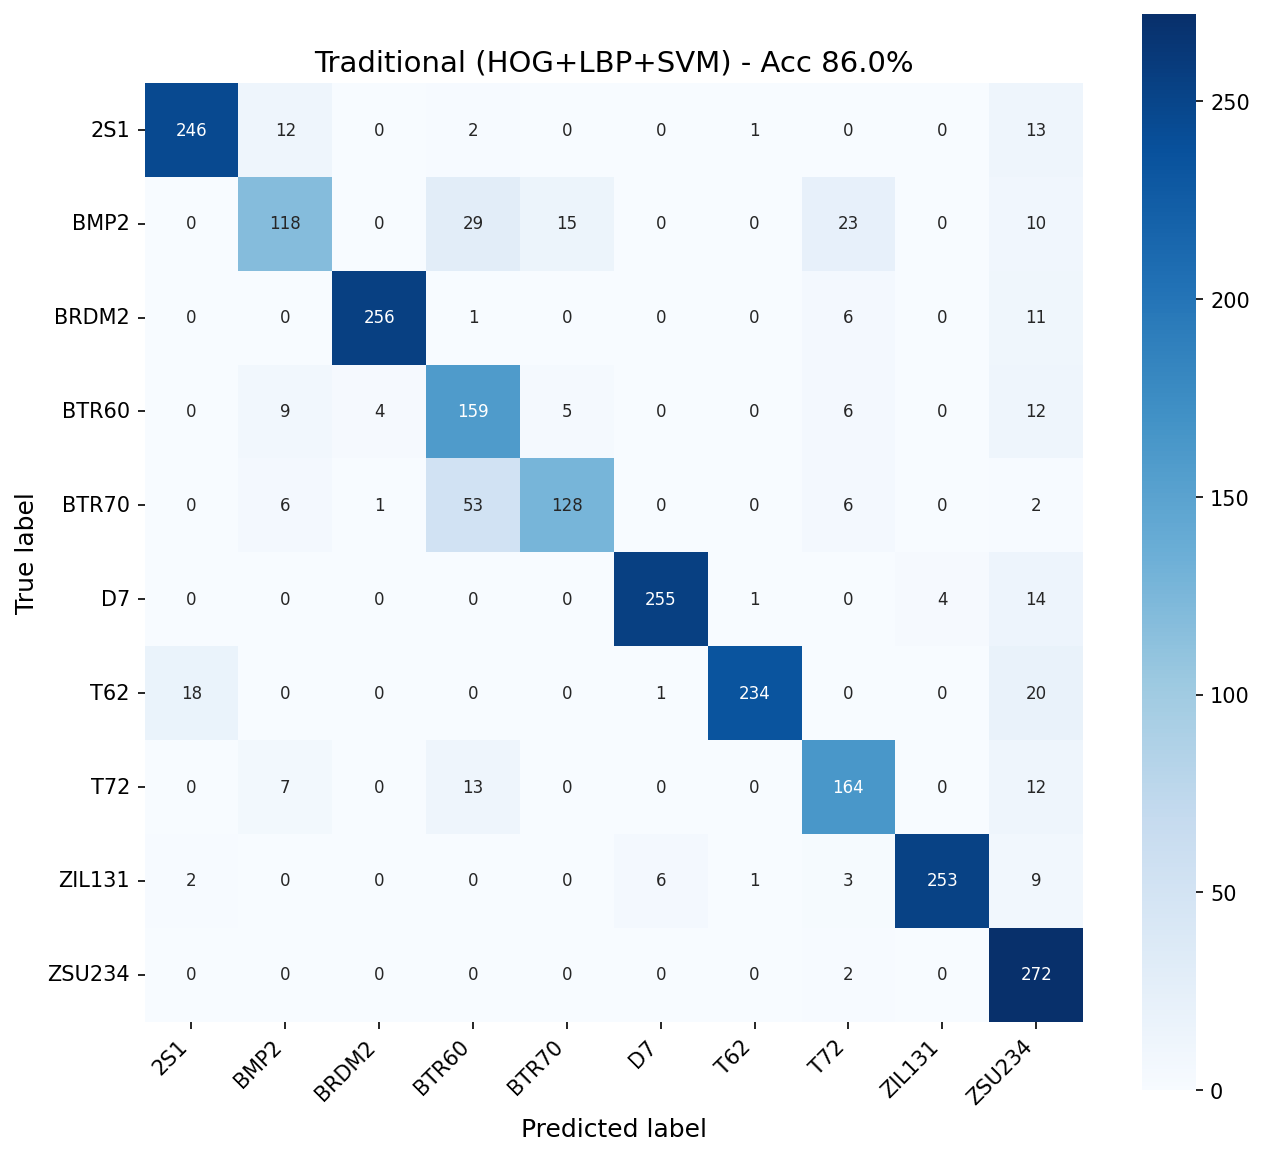

,Handcrafted+SVM
Accuracy (%),85.98
Macro-F1 (%),84.64
Macro-Precision (%),86.17
Macro-Recall (%),84.46
Train time (s),96.20
Inference (ms/img),50.03
Model size (MB),172.20


In [4]:
display(Image(filename=os.path.join(TRAD_DIR, "cm_traditional.png")))
display(pd.DataFrame({"Handcrafted+SVM": {
    "Accuracy (%)": round(metrics["accuracy"]*100, 2),
    "Macro-F1 (%)": round(metrics["macro_f1"]*100, 2),
    "Macro-Precision (%)": round(metrics["macro_precision"]*100, 2),
    "Macro-Recall (%)": round(metrics["macro_recall"]*100, 2),
    "Train time (s)": round(train_time, 1),
    "Inference (ms/img)": round(inference_ms, 2),
    "Model size (MB)": round(model_size, 1),
}}))